 Dataset chargé : 122,171 lignes × 23 colonnes
 Distribution des classes :

                  Nombre de flows  Pourcentage (%)
label                                             
Normal Traffic              26172            21.42
Blackhole Attack            26110            21.37
Wormhole Attack             26086            21.35
Sybil Attack                24077            19.71
Flooding Attack             19726            16.15

Total : 122,171 flows — 5 classes


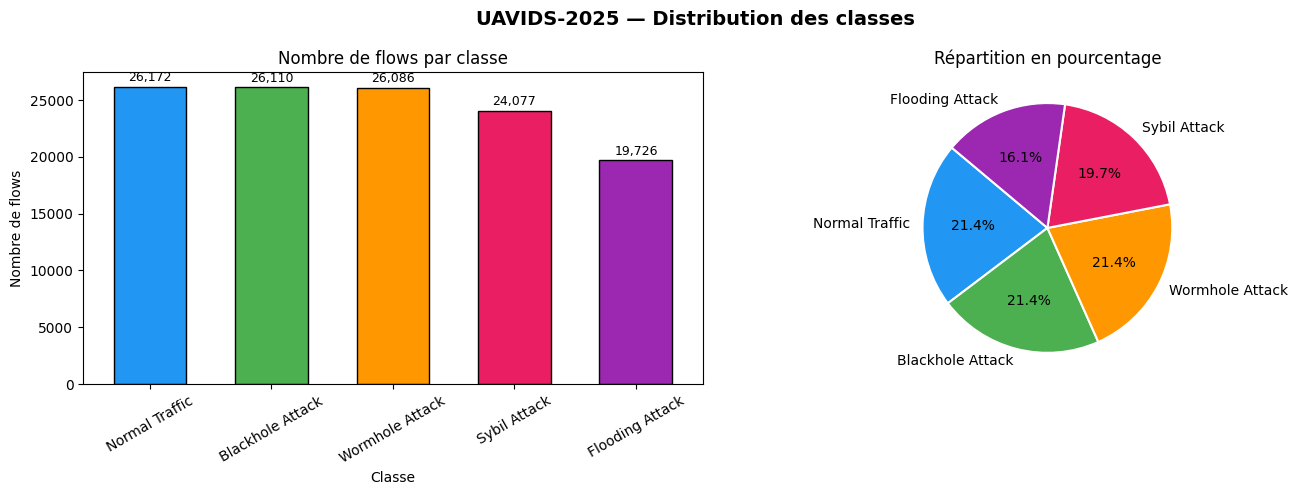

 Valeurs manquantes :

 Aucune valeur manquante détectée
 18 features numériques : ['FlowDuration/s', 'SrcPort', 'DstPort', 'TxPackets', 'RxPackets', 'LostPackets', 'TxBytes', 'RxBytes', 'TxPacketRate/s', 'RxPacketRate/s', 'TxByteRate/s', 'RxByteRate/s', 'MeanDelay/s', 'MeanJitter/s', 'Throughput/Kbps', 'MeanPacketSize', 'PacketDropRate', 'AverageHopCount']


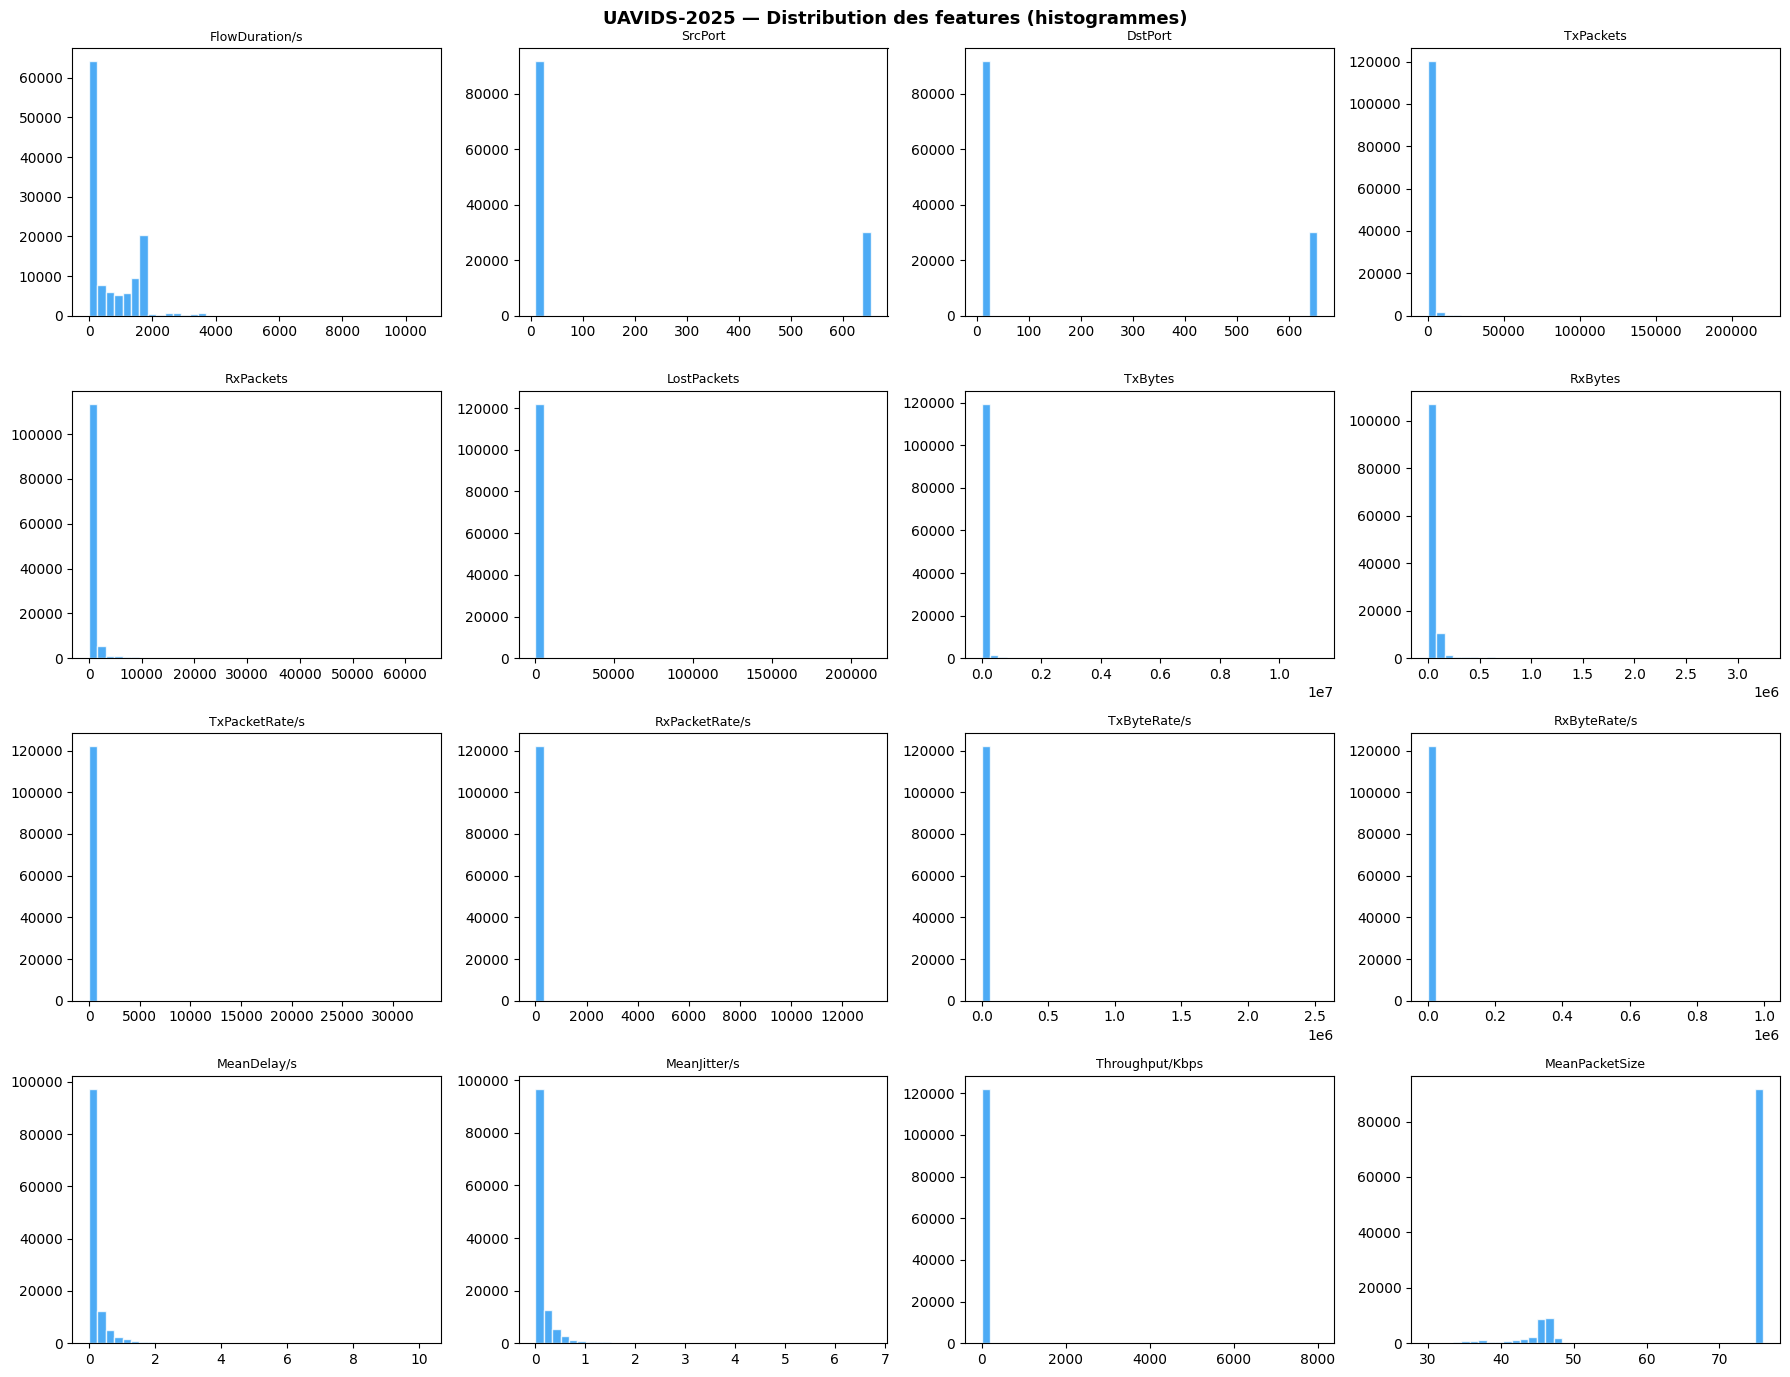

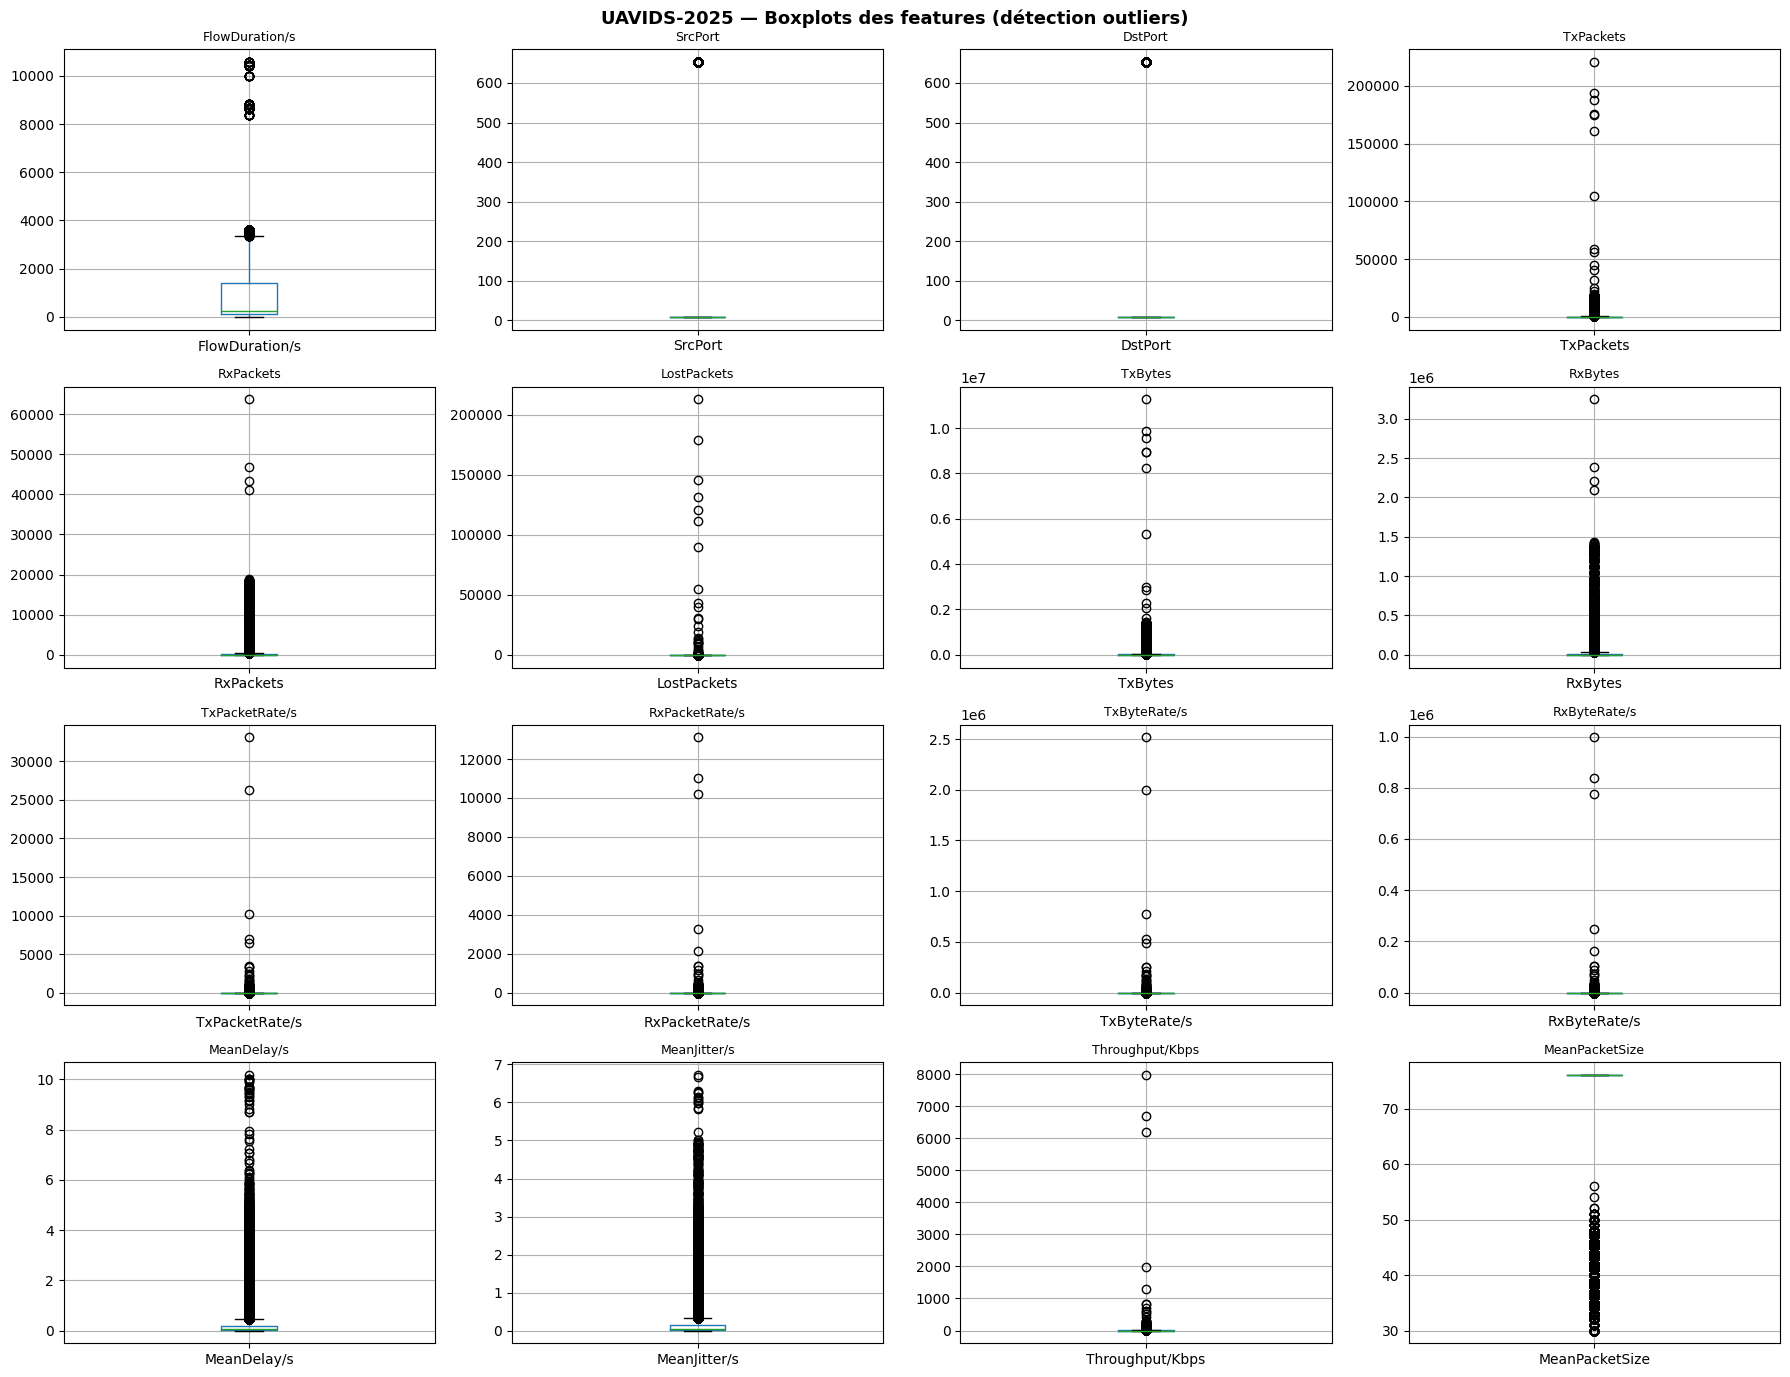

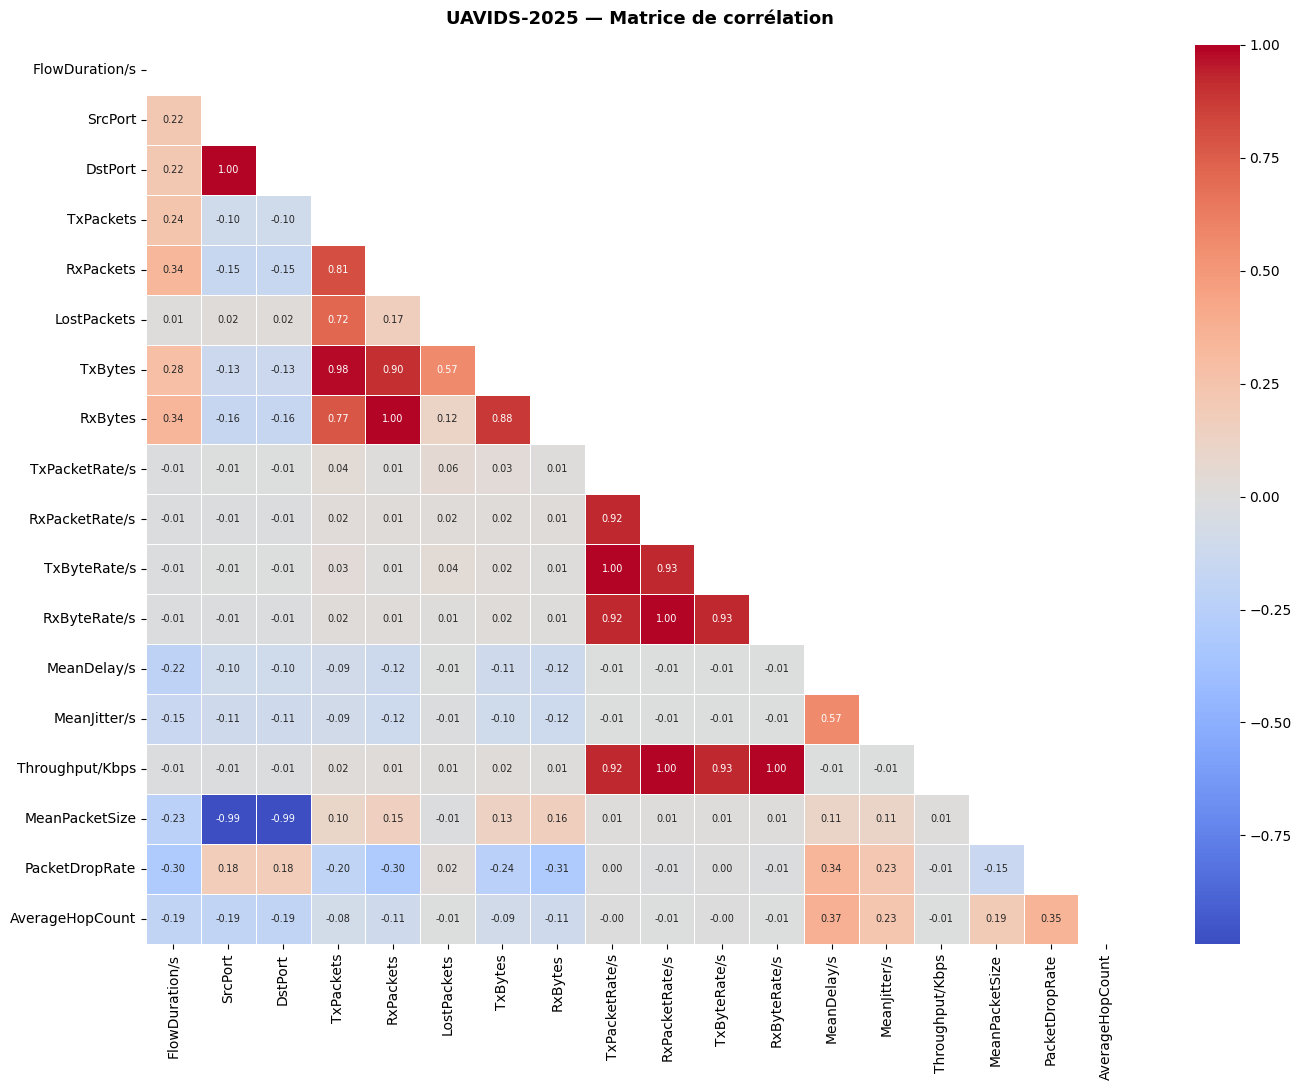

C:\Users\skhabaz\AppData\Local\Temp\ipykernel_6456\2286484552.py:186: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='label', y=col,
C:\Users\skhabaz\AppData\Local\Temp\ipykernel_6456\2286484552.py:186: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='label', y=col,
C:\Users\skhabaz\AppData\Local\Temp\ipykernel_6456\2286484552.py:186: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='label', y=col,
C:\Users\skhabaz\AppData\Local\Temp\ipykernel_6456\2286484552.py:186: FutureWarning: 

Passing `palette` with

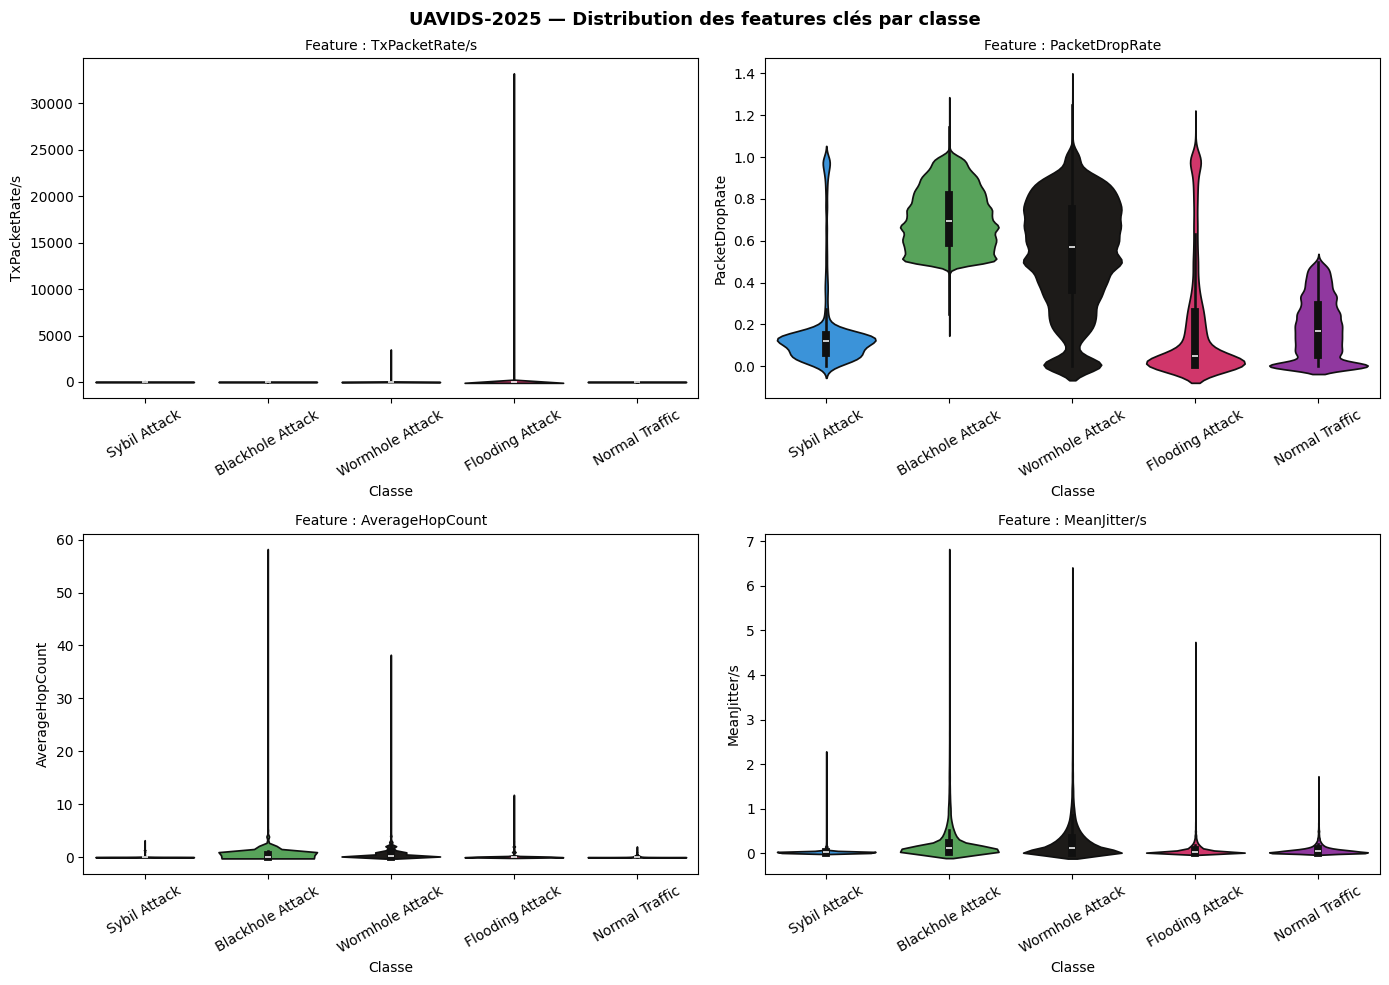

In [ ]:
# ============================================================
# NOTEBOOK : Exploration des données — UAVIDS-2025
# Dataset  : Drone swarm network intrusion detection
# ============================================================

# ────────────────────────────────────────
# 1. IMPORTATION DES LIBRAIRIES
# ────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ────────────────────────────────────────
# 2. CHARGEMENT DU DATASET
# ────────────────────────────────────────
FILE_PATH = r"C:\Drone_Attack_Similarity_Project\DATASET\UAVIDS_2025\UAVIDS-2025.csv"
df = pd.read_csv(FILE_PATH)
print(f" Dataset chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")

# ────────────────────────────────────────
# 3. DISTRIBUTION DES CLASSES
# ────────────────────────────────────────
class_counts = df['label'].value_counts()
class_pct    = (class_counts / len(df) * 100).round(2)

class_df = pd.DataFrame({
    'Nombre de flows' : class_counts,
    'Pourcentage (%)'  : class_pct
})
print(" Distribution des classes :\n")
print(class_df)
print(f"\nTotal : {len(df):,} flows — {df['label'].nunique()} classes")

# Visualisation distribution des classes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("UAVIDS-2025 — Distribution des classes",
             fontsize=14, fontweight='bold')

colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']

# Barplot
class_counts.plot(kind='bar', ax=axes[0], color=colors,
                  edgecolor='black', width=0.6)
axes[0].set_title("Nombre de flows par classe")
axes[0].set_xlabel("Classe")
axes[0].set_ylabel("Nombre de flows")
axes[0].tick_params(axis='x', rotation=30)
for bar, val in zip(axes[0].patches, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 200,
                 f'{val:,}', ha='center', va='bottom', fontsize=9)

# Pie chart
axes[1].pie(class_counts.values,
            labels=class_counts.index,
            autopct='%1.1f%%',
            colors=colors,
            startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title("Répartition en pourcentage")

plt.tight_layout()
plt.savefig("UAVIDS2025_class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()


# ────────────────────────────────────────
# 4. ANALYSE DES VALEURS MANQUANTES
# ────────────────────────────────────────
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Valeurs manquantes' : missing,
    'Pourcentage (%)'    : missing_pct
}).sort_values('Valeurs manquantes', ascending=False)

print(" Valeurs manquantes :\n")
if missing_df['Valeurs manquantes'].sum() > 0:
    print(missing_df[missing_df['Valeurs manquantes'] > 0])
    
    # Visualisation
    plt.figure(figsize=(10, 4))
    missing_df[missing_df['Valeurs manquantes'] > 0]['Pourcentage (%)'].plot(
        kind='bar', color='#E91E63', edgecolor='black')
    plt.title("Pourcentage de valeurs manquantes par feature")
    plt.ylabel("% valeurs manquantes")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig("UAVIDS2025_missing_values.png", dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(" Aucune valeur manquante détectée")

# ────────────────────────────────────────
# 5. DISTRIBUTION DES FEATURES NUMÉRIQUES
# ────────────────────────────────────────
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in ['FlowID']:
    if col in num_cols:
        num_cols.remove(col)

print(f" {len(num_cols)} features numériques : {num_cols}")

# Histogrammes
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
fig.suptitle("UAVIDS-2025 — Distribution des features (histogrammes)",
             fontsize=13, fontweight='bold')

axes_flat = axes.flatten()
for i, col in enumerate(num_cols[:16]):
    axes_flat[i].hist(df[col].dropna(), bins=40,
                      color='#2196F3', edgecolor='white', alpha=0.8)
    axes_flat[i].set_title(col, fontsize=9)
    axes_flat[i].set_xlabel("")

for j in range(len(num_cols[:16]), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.savefig("UAVIDS2025_histogrammes.png", dpi=150, bbox_inches='tight')
plt.show()

# ────────────────────────────────────────
# 6. BOXPLOTS — DÉTECTION DES OUTLIERS
# ────────────────────────────────────────
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
fig.suptitle("UAVIDS-2025 — Boxplots des features (détection outliers)",
             fontsize=13, fontweight='bold')

axes_flat = axes.flatten()
for i, col in enumerate(num_cols[:16]):
    df.boxplot(column=col, ax=axes_flat[i])
    axes_flat[i].set_title(col, fontsize=9)
    axes_flat[i].set_xlabel("")

for j in range(len(num_cols[:16]), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.savefig("UAVIDS2025_boxplots.png", dpi=150, bbox_inches='tight')
plt.show()

# ────────────────────────────────────────
# 7. MATRICE DE CORRÉLATION
# ────────────────────────────────────────
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            center=0,
            linewidths=0.4,
            annot_kws={"size": 7})
plt.title("UAVIDS-2025 — Matrice de corrélation",
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig("UAVIDS2025_correlation_matrix.png", dpi=150, bbox_inches='tight')
plt.show()


# ────────────────────────────────────────
# 8. FEATURES PAR CLASSE (violin plots)
# ────────────────────────────────────────
# Top 4 features les plus discriminantes
top_features = ['TxPacketRate/s', 'PacketDropRate', 'AverageHopCount', 'MeanJitter/s']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("UAVIDS-2025 — Distribution des features clés par classe",
             fontsize=13, fontweight='bold')

axes_flat = axes.flatten()
colors = ['#2196F3', '#4CAF50', "#1E1B18", '#E91E63', '#9C27B0']

for i, col in enumerate(top_features):
    if col in df.columns:
        sns.violinplot(data=df, x='label', y=col,
                       ax=axes_flat[i], palette=colors)
        axes_flat[i].set_title(f"Feature : {col}", fontsize=10)
        axes_flat[i].set_xlabel("Classe")
        axes_flat[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig("UAVIDS2025_violin_plots.png", dpi=150, bbox_inches='tight')
plt.show()


